# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data_short.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
148,3,7,"(0.27, 1.1)","(0.004, -0.527, 0.035, 0.442)",1,1.0,"(-0.007, -0.339, 0.044, 0.296)",0.0,1.0,"(-0.014, -0.528, 0.05, 0.455)"
102,18,5,"(0.63, 1.5)","(0.038, 0.409, -0.003, -0.34)",0,1.0,"(0.046, 0.22, -0.01, -0.181)",1.0,1.0,"(0.05, 0.409, -0.013, -0.342)"
162,17,7,"(0.27, 1.1)","(0.055, 0.977, 0.015, -0.642)",0,1.0,"(0.075, 0.788, 0.002, -0.488)",1.0,1.0,"(0.091, 0.977, -0.008, -0.639)"
202,15,9,"(0.11, 0.5)","(0.003, -0.612, 0.07, 1.021)",0,1.0,"(-0.009, -0.808, 0.09, 1.337)",1.0,1.0,"(-0.026, -0.614, 0.117, 1.072)"
9,9,0,"(0.24, 0.6)","(-0.034, -0.546, 0.018, 0.843)",0,1.0,"(-0.045, -0.741, 0.034, 1.12)",1.0,1.0,"(-0.06, -0.547, 0.057, 0.859)"
...,...,...,...,...,...,...,...,...,...,...
45,15,3,"(0.05, 1.7)","(-0.031, 0.899, 0.032, -0.349)",0,1.0,"(-0.013, 0.713, 0.025, -0.263)",1.0,1.0,"(0.001, 0.899, 0.02, -0.344)"
68,38,3,"(0.05, 1.7)","(0.424, 0.348, -0.158, -0.225)",1,1.0,"(0.431, 0.534, -0.163, -0.321)",1.0,1.0,"(0.441, 0.72, -0.169, -0.417)"
44,14,3,"(0.05, 1.7)","(-0.045, 0.714, 0.037, -0.269)",1,1.0,"(-0.031, 0.899, 0.032, -0.349)",0.0,1.0,"(-0.013, 0.713, 0.025, -0.263)"
193,6,9,"(0.11, 0.5)","(0.031, -0.022, 0.02, 0.047)",1,1.0,"(0.03, 0.173, 0.021, -0.242)",0.0,1.0,"(0.034, -0.023, 0.017, 0.06)"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.15310736000537872, 1.2852998971939087]","[0.17460837960243225, 1.1690717935562134]","[0.060696765780448914, 0.2455841451883316, 0.0...",1.809409,1.455340,0.806474
1,1,"[0.14986026287078857, 1.2881306409835815]","[0.17111757397651672, 1.1715962886810303]","[0.05918498709797859, 0.24387365579605103, 0.0...",1.809327,1.441677,0.802443
2,2,"[0.14669542014598846, 1.2909878492355347]","[0.1677071899175644, 1.1741424798965454]","[0.05769961699843407, 0.24218058586120605, 0.0...",1.809288,1.428190,0.798492
3,3,"[0.14361900091171265, 1.2938908338546753]","[0.164383202791214, 1.1767445802688599]","[0.056239981204271317, 0.2405042201280594, 0.0...",1.809290,1.414879,0.794623
4,4,"[0.1406300663948059, 1.29684579372406]","[0.1611405909061432, 1.179397463798523]","[0.05480607599020004, 0.2388441264629364, 0.01...",1.809334,1.401744,0.790834


In [4]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
148,3,7,"(0.27, 1.1)","(0.004, -0.527, 0.035, 0.442)",1,1.0,"(-0.007, -0.339, 0.044, 0.296)",0.0,1.0,"(-0.014, -0.528, 0.05, 0.455)"
102,18,5,"(0.63, 1.5)","(0.038, 0.409, -0.003, -0.34)",0,1.0,"(0.046, 0.22, -0.01, -0.181)",1.0,1.0,"(0.05, 0.409, -0.013, -0.342)"
162,17,7,"(0.27, 1.1)","(0.055, 0.977, 0.015, -0.642)",0,1.0,"(0.075, 0.788, 0.002, -0.488)",1.0,1.0,"(0.091, 0.977, -0.008, -0.639)"
202,15,9,"(0.11, 0.5)","(0.003, -0.612, 0.07, 1.021)",0,1.0,"(-0.009, -0.808, 0.09, 1.337)",1.0,1.0,"(-0.026, -0.614, 0.117, 1.072)"
9,9,0,"(0.24, 0.6)","(-0.034, -0.546, 0.018, 0.843)",0,1.0,"(-0.045, -0.741, 0.034, 1.12)",1.0,1.0,"(-0.06, -0.547, 0.057, 0.859)"


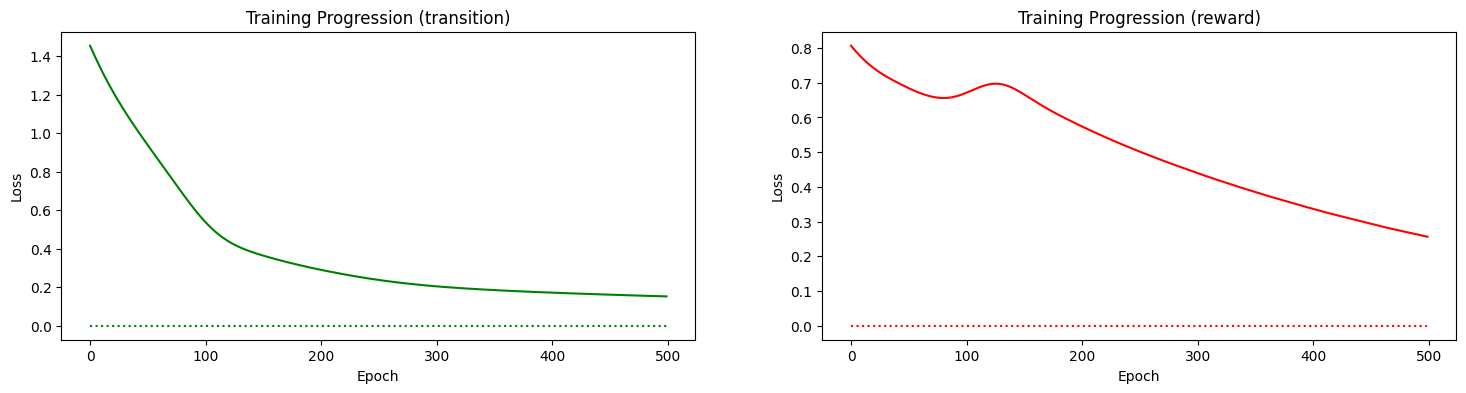

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

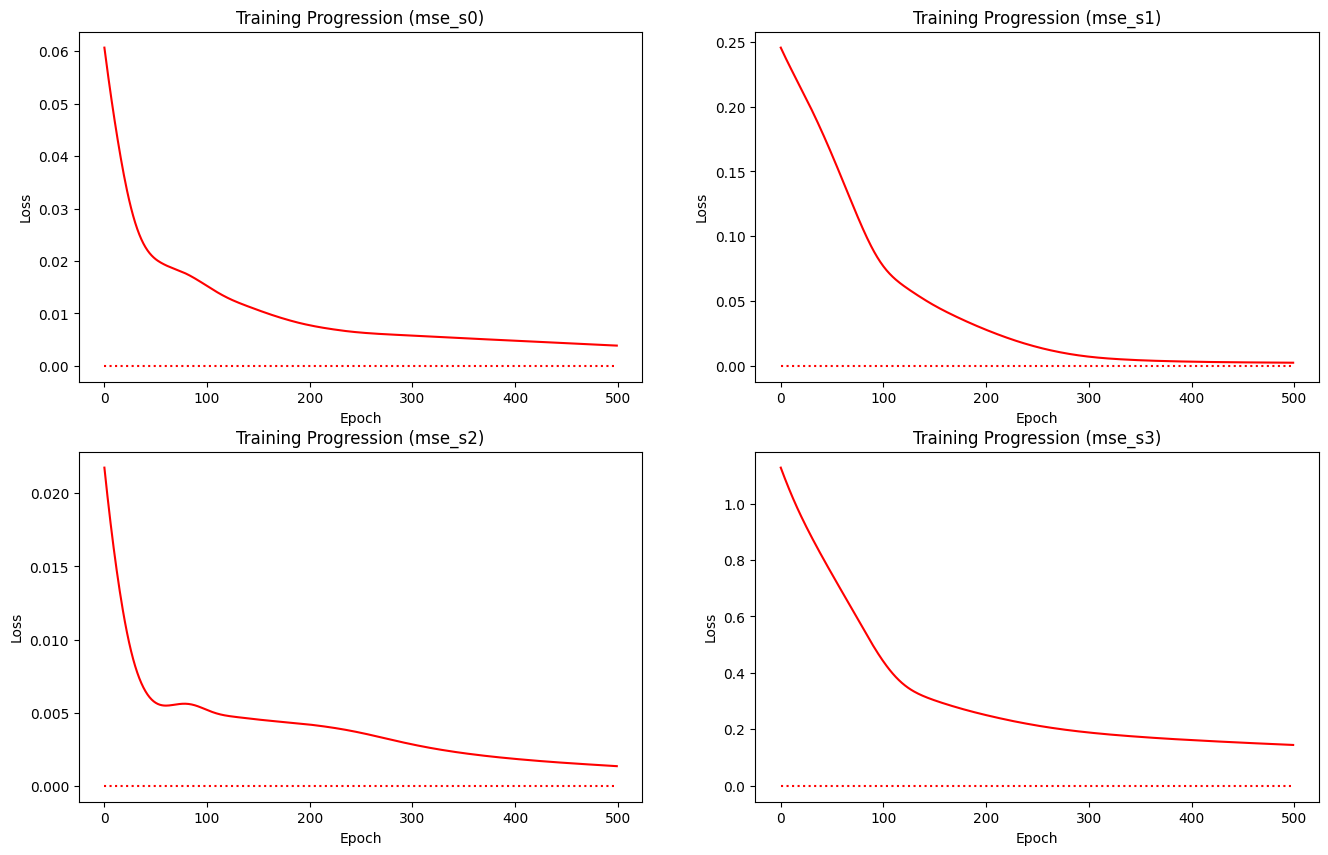

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

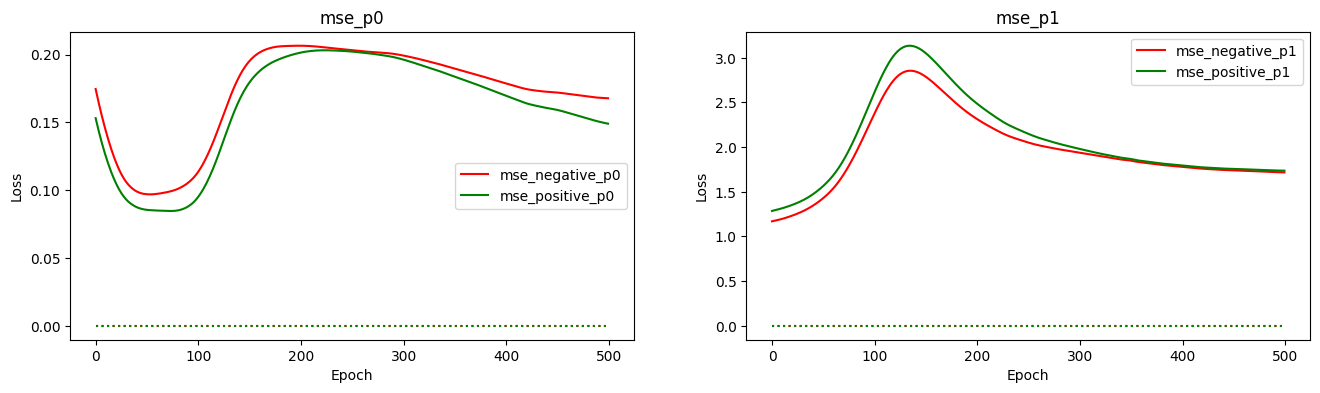

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

In [30]:
import pandas as pd

traimimg_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data, expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = traimimg_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_6884/2252776873.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,0,0.27,1.1,0.63,1.5,0.458933,0.120421,0.0
1,0,0.63,1.5,0.27,1.1,0.148282,0.209086,1.0
2,0,0.27,1.1,0.63,1.5,0.034697,0.133214,2.0
3,0,0.11,0.5,0.63,0.6,0.483513,0.110156,3.0
4,0,0.24,0.6,0.27,1.1,0.450419,0.134603,4.0


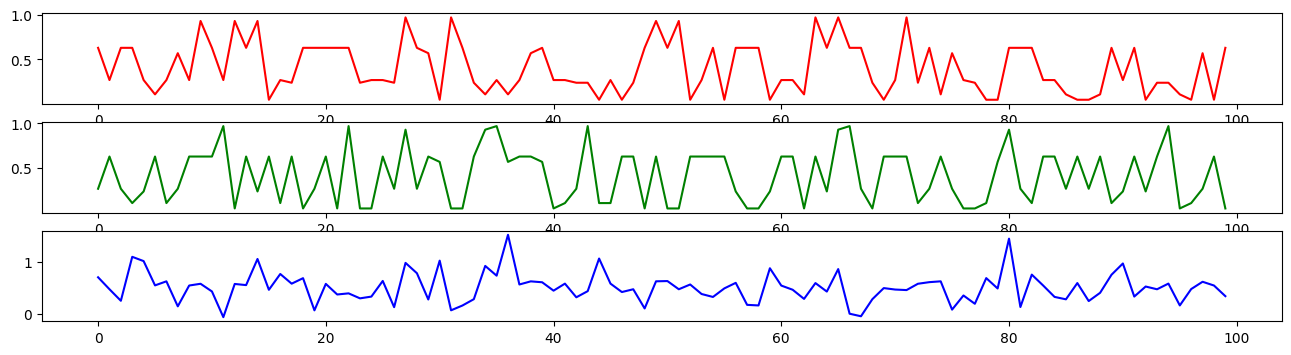

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

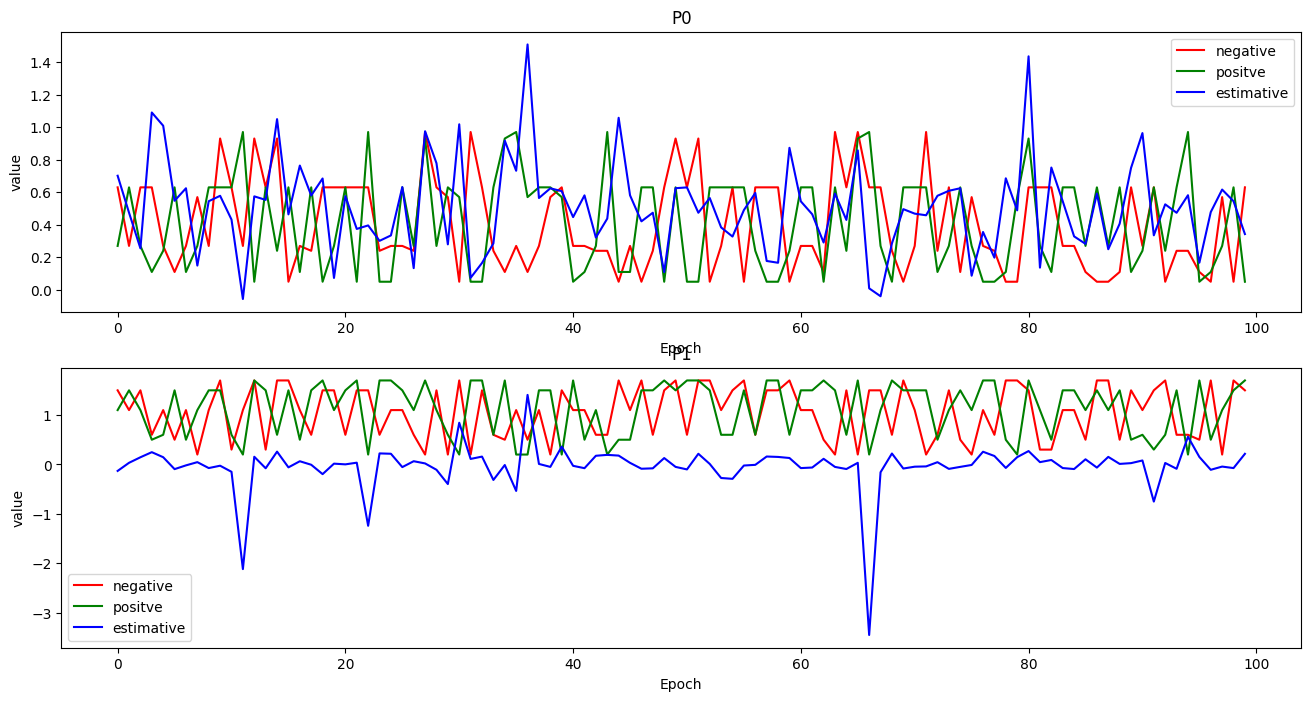

In [47]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [7]:
data.evaluate_model(model, path='training_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.24, 0.6)","(-0.041, 0.037, 0.015, -0.0)",0,1.0,"(-0.04, -0.157, 0.015, 0.276)",1.0,1.0,"(-0.043, 0.037, 0.02, 0.009)",...,0.054,0.24,0.6,0.108,0.495,0.032,0.022,0.016,0.045,0.7
1,1,0,"(0.24, 0.6)","(-0.04, -0.157, 0.015, 0.276)",1,1.0,"(-0.043, 0.037, 0.02, 0.009)",1.0,1.0,"(-0.042, 0.231, 0.02, -0.257)",...,-0.271,0.24,0.6,0.195,0.354,0.055,0.023,0.025,0.014,0.6
2,2,0,"(0.24, 0.6)","(-0.043, 0.037, 0.02, 0.009)",1,1.0,"(-0.042, 0.231, 0.02, -0.257)",1.0,1.0,"(-0.038, 0.425, 0.015, -0.523)",...,-0.500,0.24,0.6,0.188,0.264,0.082,0.013,0.055,0.023,0.5
3,3,0,"(0.24, 0.6)","(-0.042, 0.231, 0.02, -0.257)",1,1.0,"(-0.038, 0.425, 0.015, -0.523)",0.0,1.0,"(-0.029, 0.23, 0.005, -0.247)",...,-0.256,0.24,0.6,0.185,0.175,0.092,0.038,0.060,0.009,0.6
4,4,0,"(0.24, 0.6)","(-0.038, 0.425, 0.015, -0.523)",0,1.0,"(-0.029, 0.23, 0.005, -0.247)",0.0,1.0,"(-0.025, 0.036, -0.0, 0.026)",...,0.073,0.24,0.6,0.153,0.300,0.060,0.003,0.021,0.047,0.7


In [8]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([9, 0, 5]) worst_episodes=array([1, 2, 6])


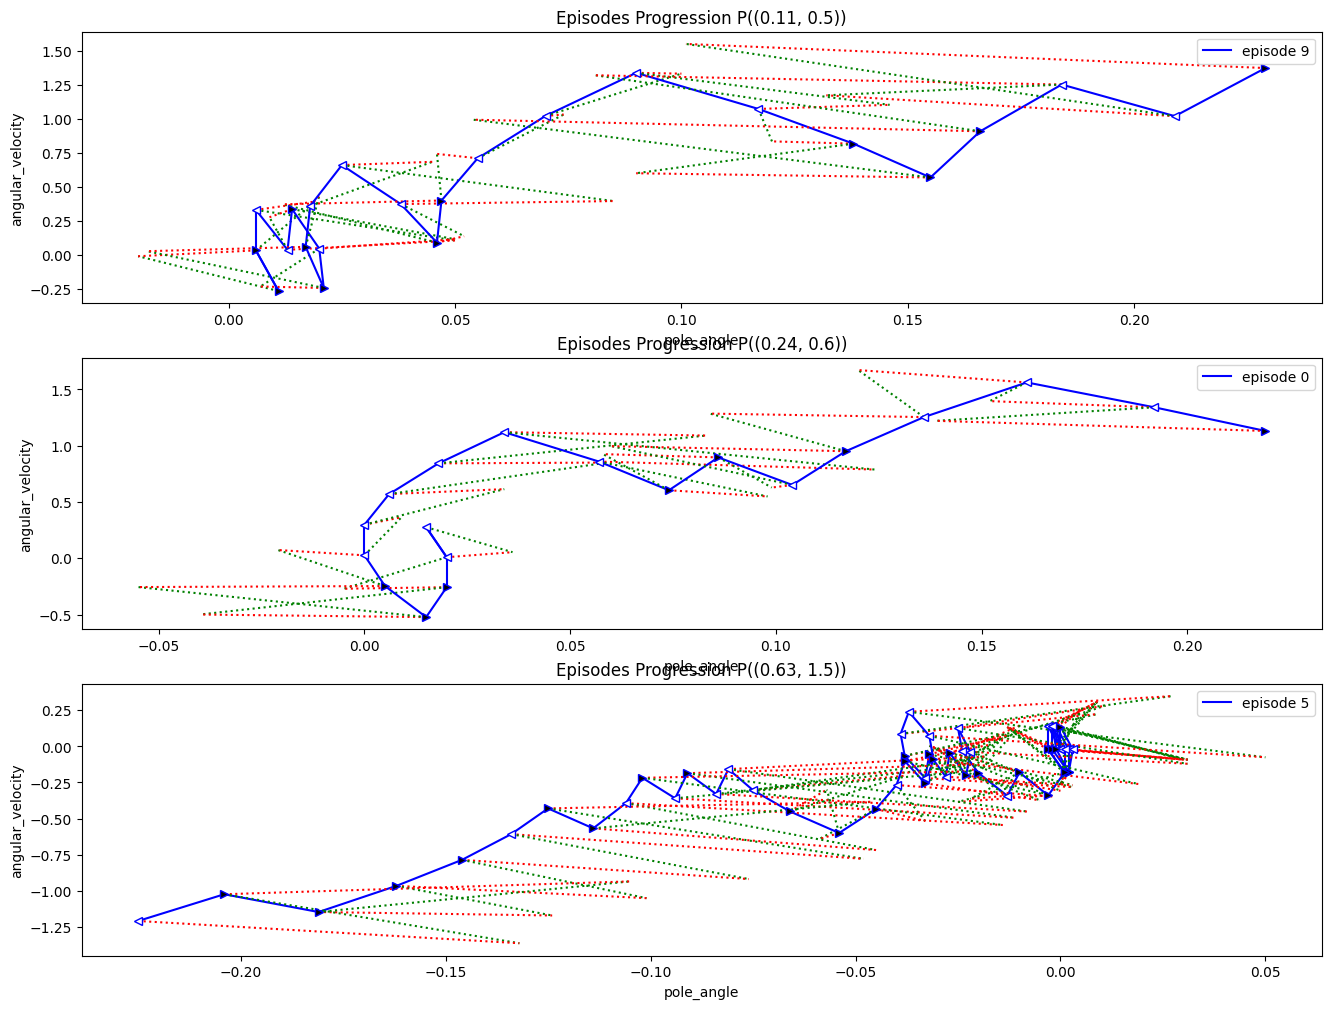

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

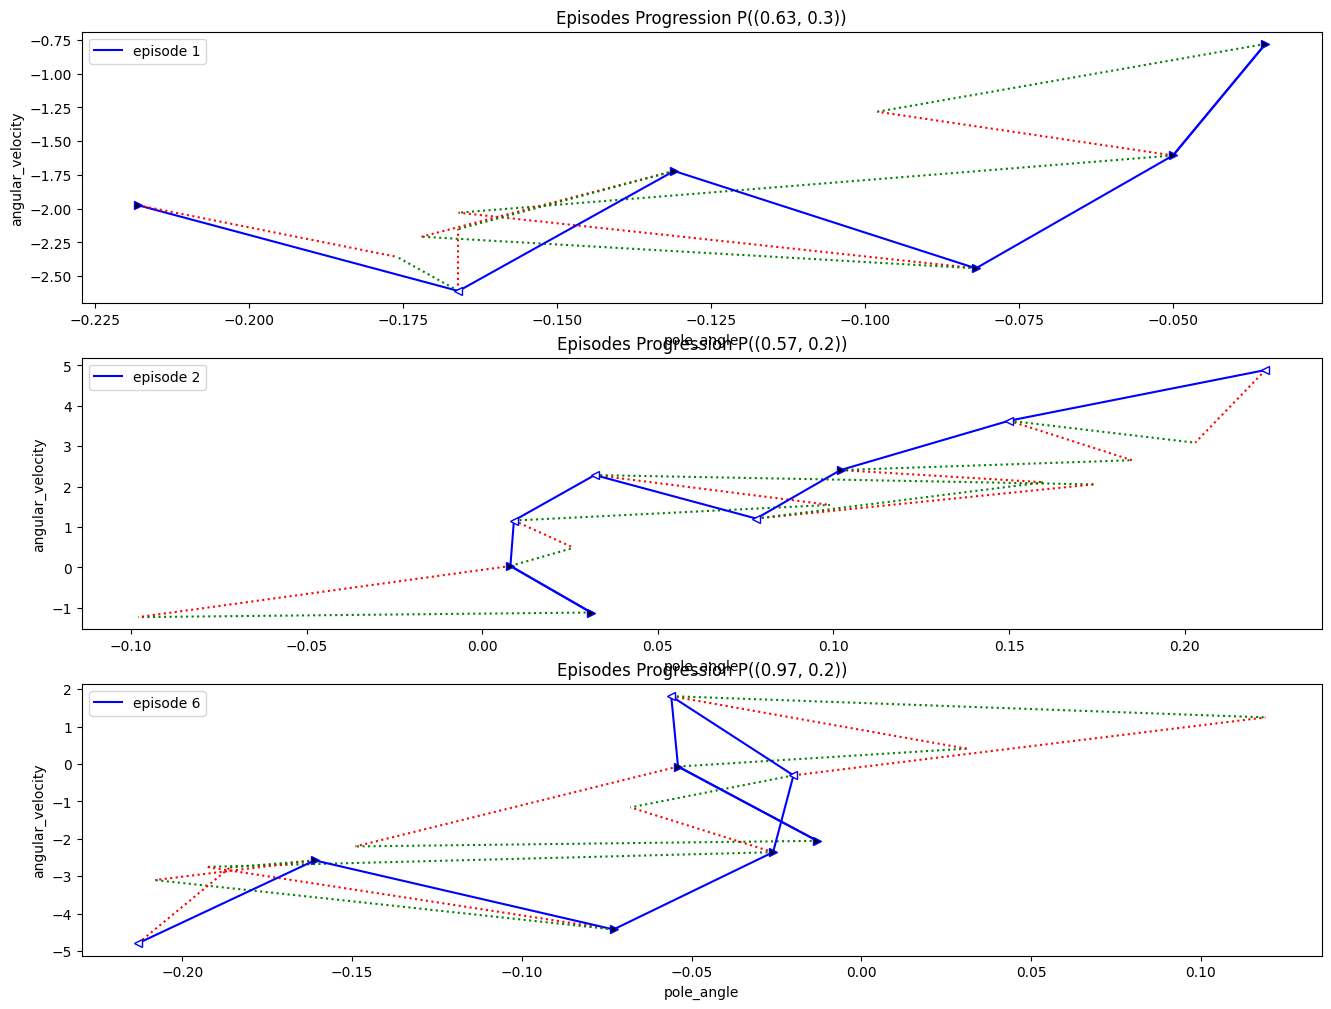

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

# Evaluation

In [11]:
data.evaluate_model(model, path='testing_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.27, 1.9)","(-0.037, 0.026, -0.021, 0.016)",0,1.0,"(-0.036, -0.159, -0.02, 0.102)",0.0,1.0,"(-0.04, -0.345, -0.018, 0.188)",...,0.329,0.27,1.9,0.237,0.414,0.017,0.055,0.035,0.141,0.8
1,1,0,"(0.27, 1.9)","(-0.036, -0.159, -0.02, 0.102)",0,1.0,"(-0.04, -0.345, -0.018, 0.188)",0.0,1.0,"(-0.047, -0.531, -0.014, 0.274)",...,0.347,0.27,1.9,0.323,0.452,0.001,0.071,0.043,0.073,0.9
2,2,0,"(0.27, 1.9)","(-0.04, -0.345, -0.018, 0.188)",0,1.0,"(-0.047, -0.531, -0.014, 0.274)",1.0,1.0,"(-0.057, -0.345, -0.009, 0.185)",...,-0.066,0.27,1.9,0.364,0.524,0.007,0.006,0.068,0.251,0.8
3,3,0,"(0.27, 1.9)","(-0.047, -0.531, -0.014, 0.274)",1,1.0,"(-0.057, -0.345, -0.009, 0.185)",0.0,1.0,"(-0.064, -0.531, -0.005, 0.272)",...,0.386,0.27,1.9,0.304,0.471,0.017,0.070,0.036,0.114,0.9
4,4,0,"(0.27, 1.9)","(-0.057, -0.345, -0.009, 0.185)",0,1.0,"(-0.064, -0.531, -0.005, 0.272)",1.0,1.0,"(-0.075, -0.345, 0.0, 0.183)",...,-0.064,0.27,1.9,0.359,0.517,0.022,0.006,0.058,0.247,0.8


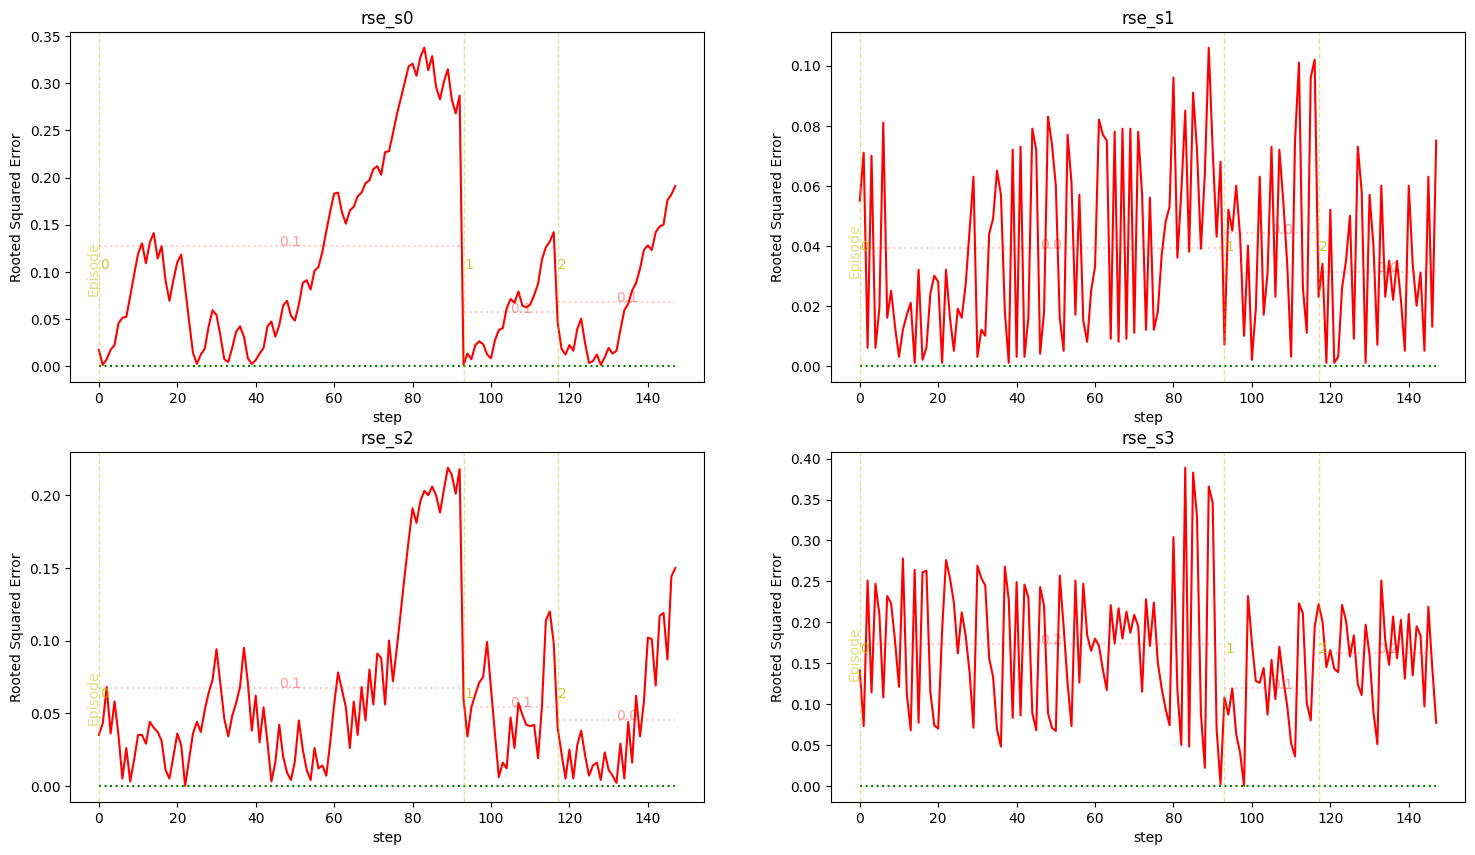

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

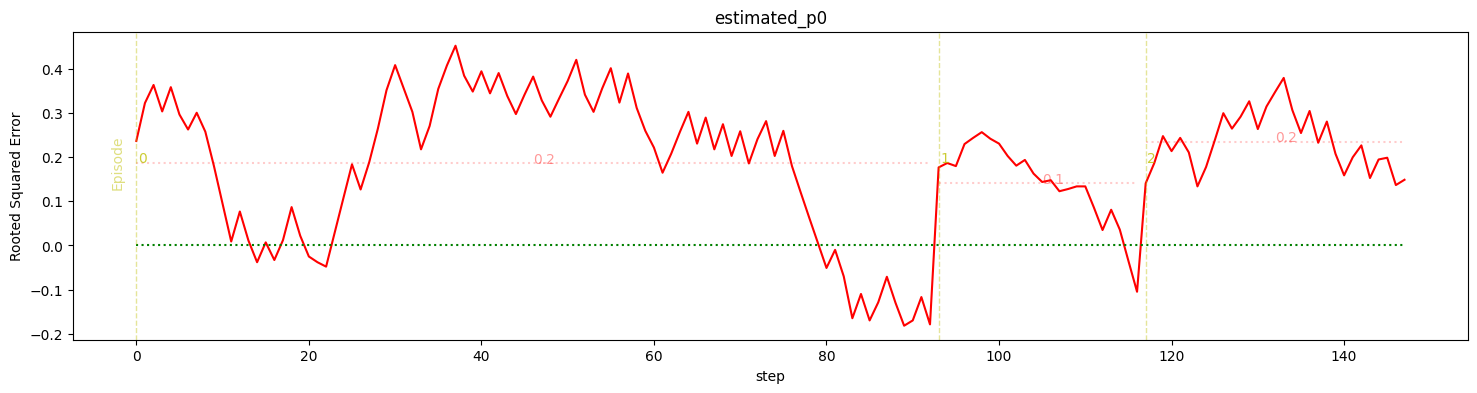

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

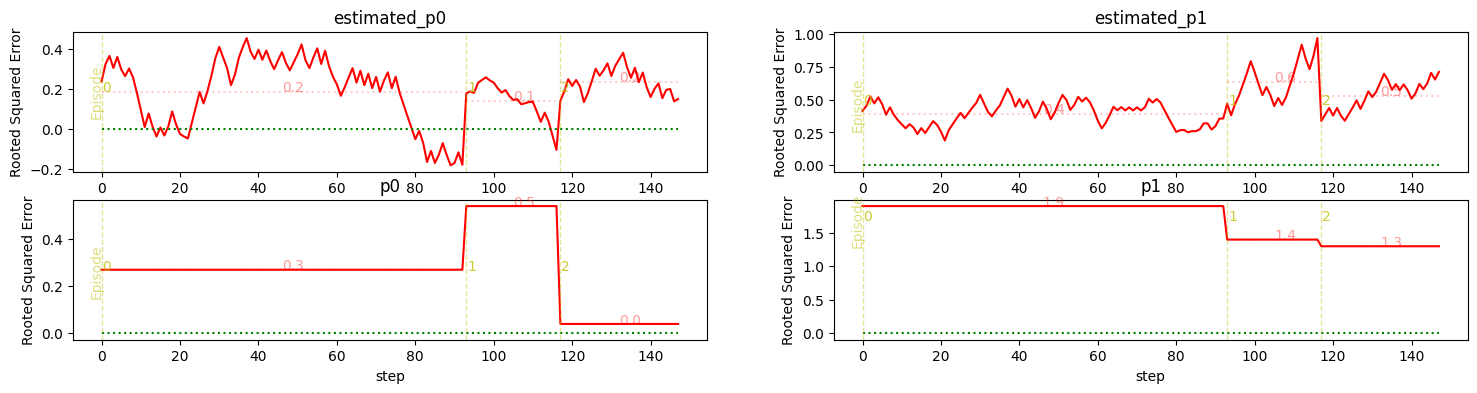

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], results, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], results, 'estimated_p1', y_label='value')
data.plot_value_through_episodes(axs[1][0], results, 'p0', y_label='value')
data.plot_value_through_episodes(axs[1][1], results, 'p1', y_label='value')
plt.show()

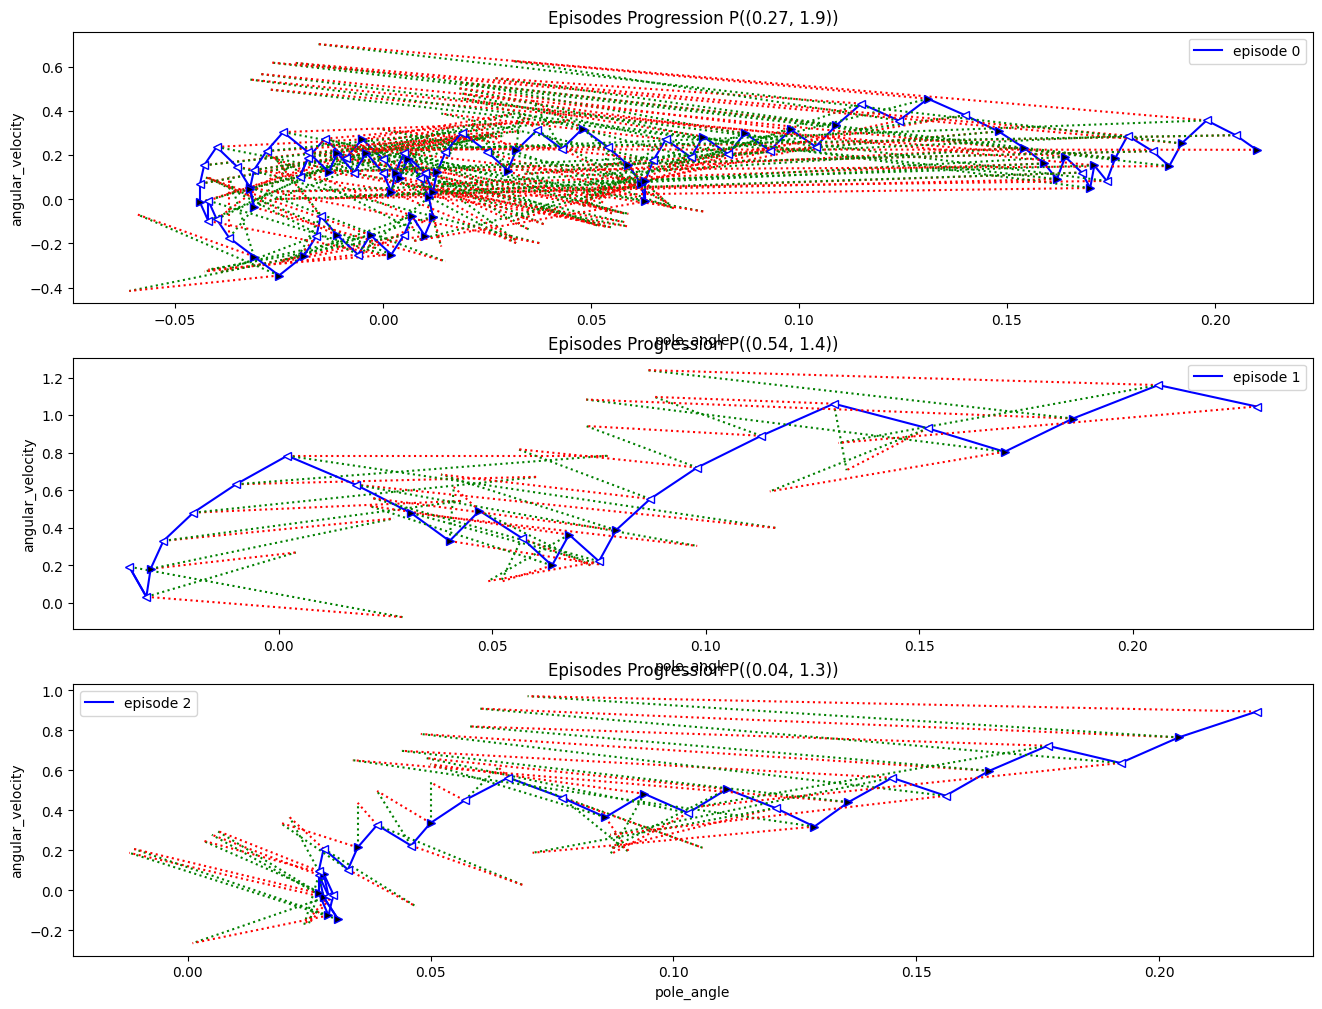

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()